# Dollar bars and cross-asset alignment

Trim assets to their common date window, build dollar bars per asset, then align them onto a shared calendar grid via backward-fill join. Plot bar counts/spacing per asset before and after alignment to sanity check the fix.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.data.loader import KrakenTickLoader
from src.data.bars import CommonWindowTrimmer, DollarBarBuilder
from src.data.alignment import CalendarAligner

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
ASSET_PALETTE = dict(zip(["SOL", "BCH", "ADA", "XRP"], sns.color_palette("Set2", 4)))

config = load_config("../config/config.yaml")
config

{'assets': ['SOL', 'BCH', 'ADA', 'XRP'],
 'pairs': [['SOL', 'BCH'],
  ['SOL', 'ADA'],
  ['SOL', 'XRP'],
  ['BCH', 'ADA'],
  ['BCH', 'XRP'],
  ['ADA', 'XRP']],
 'data': {'raw_dir': 'data/raw',
  'processed_dir': 'data/processed',
  'target_bars': 2000},
 'alignment': {'method': 'calendar_join',
  'grid_freq': '1h',
  'common_start': '2021-06-17'},
 'cointegration': {'test': 'engle_granger',
  'window_type': 'random',
  'n_windows': 50,
  'window_length_days': 30,
  'significance_level': 0.05,
  'random_seed': 42},
 'hedge_ratio': {'method': 'kalman',
  'delta': 0.0001,
  'observation_covariance': 0.001},
 'signal': {'lookback': 60, 'entry_z': 2.0, 'exit_z': 0.5},
 'backtest': {'cost_model': 'bps_per_side',
  'cost_bps': 5,
  'train_test_split': 'walk_forward',
  'out_of_sample_fraction': 0.3}}

In [2]:
asset_paths = {ticker: f"../data/raw/{ticker}.csv" for ticker in config["assets"]}
assets = KrakenTickLoader().load_all(asset_paths)

SOL: 26,417,225 ticks | 2021-06-17 15:32:57 -> 2025-12-31 23:59:48


BCH: 9,395,447 ticks | 2017-08-01 16:01:37 -> 2025-12-31 23:53:58


ADA: 18,513,865 ticks | 2018-09-28 13:25:00 -> 2025-12-31 23:59:43


XRP: 30,957,309 ticks | 2017-05-18 15:46:56 -> 2025-12-31 23:59:57


## Trim to the common window

SOL's 2021-06-17 start is the binding constraint (see notebook 01). Every asset's tick series is trimmed to `[max(start), min(end)]` across all four **before** any dollar-bar threshold is derived - sizing thresholds on each asset's full history first, then trimming, was the failure mode flagged in `src/data/bars.py`.

In [3]:
trimmed, common_start, common_end = CommonWindowTrimmer().fit_transform(assets)
print(f"common window: {common_start} -> {common_end}")
for ticker, df in trimmed.items():
    print(f"{ticker}: {df.height:,} ticks in the common window")

common window: 2021-06-17 15:32:57 -> 2025-12-31 23:53:58
SOL: 26,417,169 ticks in the common window
BCH: 3,436,276 ticks in the common window
ADA: 12,889,734 ticks in the common window
XRP: 20,422,956 ticks in the common window


## Dollar bars

Bucket each (trimmed) asset's ticks by cumulative dollar volume, targeting `target_bars` buckets per asset (from config).

**Why dollar bars, not clock-time bars?** This isn't just an academic IID argument - it's the same reasoning a trading desk applies to sampling and execution, not just backtest hygiene:

- Crypto trades 24/7, but liquidity and information arrival don't. A fixed-length time bar (e.g. 1 hour) samples a quiet Sunday-night stretch and a large-flow event identically, even though one contains far more genuine price discovery than the other - that heteroskedasticity and serial dependence is exactly what the Engle-Granger/ADF tests two notebooks from now *assume away*. Feeding them clock-time bars would quietly bias the significance levels being reported.
- Dollar bars close once a fixed notional has traded, so each one represents a roughly comparable amount of economic activity regardless of when it happened - empirically closer to IID and closer to Normal than time bars (Lopez de Prado, *Advances in Financial Machine Learning*, ch. 2 - also the basis for this project's own `lopez-de-prado-checker` audit skill).
- Dollar bars specifically (not volume bars) matter here because these assets move by an order of magnitude in price over the sample - SOL alone ranges roughly \$8 to \$296. A volume bar (fixed number of coins) would represent wildly different dollar risk before and after a move like that; a dollar bar stays comparable in economic terms throughout - the same reason execution algorithms (VWAP, percentage-of-volume, implementation-shortfall schedules) are scheduled against traded value, not the clock.
- The honest trade-off: none of this survives needing a *shared* clock across four assets to run a pairwise test at all - hence the calendar-grid backward-fill step immediately after, which reintroduces a time axis by necessity. That's a disclosed compromise, not a contradiction of the reasoning above.

In [4]:
target_bars = config["data"]["target_bars"]
builder = DollarBarBuilder(target_bars=target_bars)
bars = {ticker: builder.build(df) for ticker, df in trimmed.items()}

bar_summary = pl.DataFrame([
    {
        "asset": ticker,
        "n_bars": b.height,
        "start": b["timestamp"].min(),
        "end": b["timestamp"].max(),
        "median_ticks_per_bar": int(b["n_ticks"].median()),
        "median_dollar_volume_per_bar": round(b["dollar_volume"].median(), 2),
    }
    for ticker, b in bars.items()
]).sort("asset")
bar_summary.write_csv("../outputs/tables/dollar_bars_summary.csv")
bar_summary

asset,n_bars,start,end,median_ticks_per_bar,median_dollar_volume_per_bar
str,i64,datetime[μs],datetime[μs],i64,f64
"""ADA""",2001,2021-06-17 20:18:20,2025-12-31 23:52:45,5704,8.3216e6
"""BCH""",2001,2021-06-17 20:58:27,2025-12-31 23:53:58,1617,1.0481e6
"""SOL""",2001,2021-07-08 22:29:24,2025-12-31 23:53:27,11882,2.8676e7
"""XRP""",2000,2021-06-21 06:35:49,2025-12-31 23:53:35,9032,1.9655e7


## Bar spacing before alignment

Dollar bars are NOT evenly spaced in calendar time - a bar closes whenever enough dollar volume has traded, so quiet periods produce widely-spaced bars and active periods produce tightly-spaced ones. The histogram below (log-scaled x-axis) shows just how different that spacing distribution is across assets, which is exactly why a naive `merge_asof` across four independently-bucketed series produced so few overlapping timestamps.

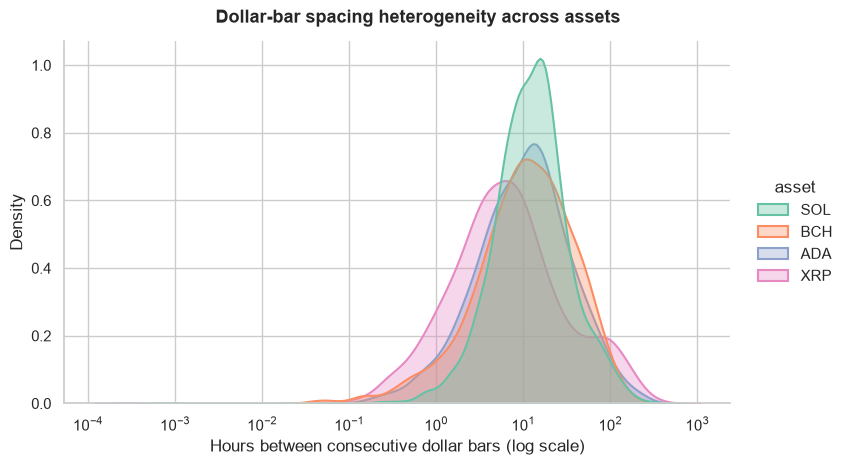

In [5]:
gap_frames = []
for ticker, b in bars.items():
    ts = b["timestamp"].to_pandas()
    gaps_hours = ts.diff().dt.total_seconds().dropna() / 3600
    gap_frames.append(pd.DataFrame({"asset": ticker, "gap_hours": gaps_hours}))
gap_df = pd.concat(gap_frames, ignore_index=True)
gap_df = gap_df[gap_df["gap_hours"] > 0]

g = sns.displot(
    data=gap_df, x="gap_hours", hue="asset", kind="kde", fill=True, common_norm=False,
    palette=ASSET_PALETTE, height=4.5, aspect=1.7, log_scale=True, alpha=0.35, linewidth=1.5,
)
g.set_axis_labels("Hours between consecutive dollar bars (log scale)", "Density")
g.figure.suptitle("Dollar-bar spacing heterogeneity across assets", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/dollar_bar_spacing.png", dpi=150)

## Align onto a shared calendar grid

Chosen fix (see `src/data/alignment.py`): build a fixed-frequency grid (`alignment.grid_freq` from config, default hourly) spanning the common window, and backward-fill each asset's last-known dollar-bar close onto every grid timestamp. This trades a small amount of staleness (a grid point can repeat the same bar value for a while in a quiet period) for a consistent, joinable time axis across all four assets - which a bar-native join could not deliver past two assets.

In [6]:
aligner = CalendarAligner(freq=config["alignment"]["grid_freq"])
aligned = aligner.align(bars)
print(f"aligned grid: {aligned.height:,} rows, {aligned['timestamp'].min()} -> {aligned['timestamp'].max()}")
aligned.write_parquet("../data/processed/aligned.parquet")
aligned.head()

aligned grid: 39,289 rows, 2021-07-08 23:18:20 -> 2025-12-31 23:18:20


timestamp,SOL_price,BCH_price,ADA_price,XRP_price,SOL_return,BCH_return,ADA_return,XRP_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2021-07-08 23:18:20,33.0,495.05,1.336302,0.67377,null,null,null,null
2021-07-09 00:18:20,33.0,495.05,1.336302,0.67377,0.0,0.0,0.0,0.0
2021-07-09 01:18:20,33.0,495.05,1.336302,0.67377,0.0,0.0,0.0,0.0
2021-07-09 02:18:20,33.0,495.05,1.336302,0.67377,0.0,0.0,0.0,0.0
2021-07-09 03:18:20,33.0,495.05,1.336302,0.67377,0.0,0.0,0.0,0.0


## Sanity check: aligned price paths

Each asset's price, indexed to 100 at the start of the aligned grid, all on the same hourly time axis. If alignment worked, every series should be a step function of its own dollar bars (flat between bars, jumping at each new bar) rather than showing gaps or misalignment.

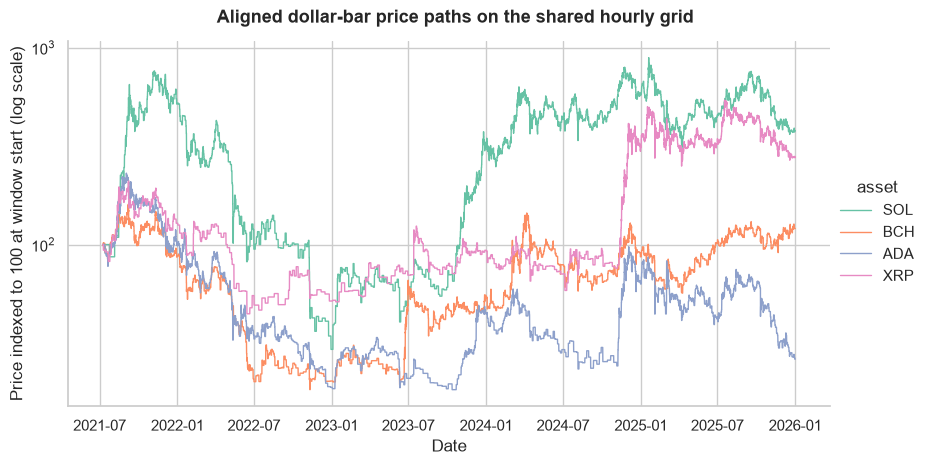

In [7]:
aligned_pd = aligned.to_pandas()
indexed = aligned_pd[["timestamp"]].copy()
for ticker in config["assets"]:
    indexed[ticker] = aligned_pd[f"{ticker}_price"] / aligned_pd[f"{ticker}_price"].iloc[0] * 100
indexed_long = indexed.melt(id_vars="timestamp", var_name="asset", value_name="indexed_price")

g = sns.relplot(
    data=indexed_long, x="timestamp", y="indexed_price", hue="asset", kind="line",
    palette=ASSET_PALETTE, height=4.5, aspect=1.9, linewidth=1,
)
g.set(yscale="log")
g.set_axis_labels("Date", "Price indexed to 100 at window start (log scale)")
g.figure.suptitle("Aligned dollar-bar price paths on the shared hourly grid", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/aligned_price_paths.png", dpi=150)

## Honest limitation: backward-fill duplication

With `target_bars` ≈ 2,000 per asset spread over roughly 4.5 years, each asset only gets a new dollar bar every ~19 hours on average - but the grid is hourly. That means most grid rows within a run just repeat the last bar's close via backward-fill, rather than reflecting a genuinely new observation. The chart below shows the distribution of "run lengths" (consecutive hourly grid rows sharing the same price) per asset. This is a real limitation of the calendar-grid approach worth being upfront about: it buys a consistent joinable time axis across assets with very different bar spacing, at the cost of a lot of duplicated/stale rows feeding into the cointegration scan downstream.

asset
ADA    11.0
BCH    12.0
SOL    13.0
XRP     7.0
Name: run_length_hours, dtype: float64


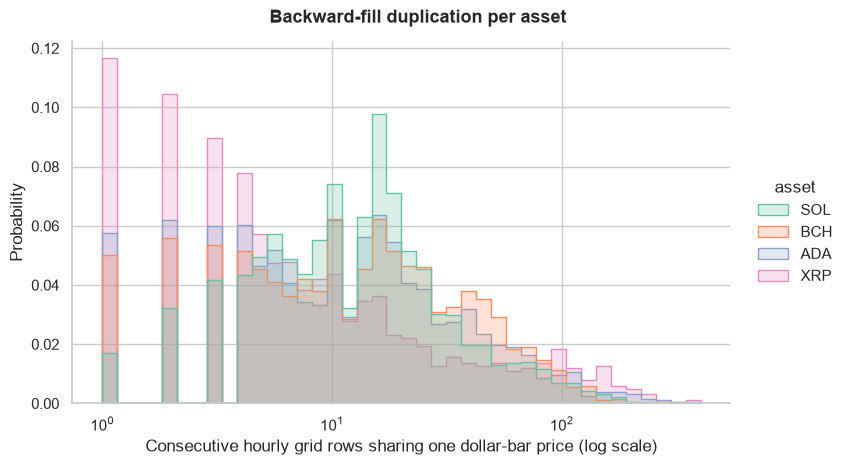

In [8]:
run_length_frames = []
for ticker in config["assets"]:
    prices = aligned_pd[f"{ticker}_price"].to_numpy()
    change_points = np.flatnonzero(np.diff(prices) != 0) + 1
    change_points = np.concatenate([[0], change_points, [len(prices)]])
    run_lengths = np.diff(change_points)
    run_length_frames.append(pd.DataFrame({"asset": ticker, "run_length_hours": run_lengths}))
run_df = pd.concat(run_length_frames, ignore_index=True)

g = sns.displot(
    data=run_df, x="run_length_hours", hue="asset", kind="hist", element="step",
    palette=ASSET_PALETTE, height=4.5, aspect=1.7, log_scale=(True, False), stat="probability", common_norm=False,
)
g.set_axis_labels("Consecutive hourly grid rows sharing one dollar-bar price (log scale)", "Probability")
g.figure.suptitle("Backward-fill duplication per asset", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/backfill_duplication.png", dpi=150)

print(run_df.groupby("asset")["run_length_hours"].median())

## Takeaways

- Dollar bars per asset land close to the `target_bars` = 2,000 target, but their calendar spacing is highly uneven (see the spacing KDE above) - confirming why a bar-native join across assets is a dead end past two series.
- The calendar-grid backward-fill join produces a clean, fully joinable hourly panel across all four assets with no missing values once the warm-up period (before every asset has at least one bar) is dropped.
- The cost of that join method is real: the median backward-fill run length is many hours long per asset, meaning a large share of hourly grid rows are repeats rather than fresh information. This effectively lowers the sample size behind the cointegration scan in the next step, and is called out explicitly in the README's limitations section rather than glossed over.